In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df=pd.read_csv('/content/Fishers maket.csv')
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [ ]:
df.shape

(159, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [ ]:
df.tail()

,Species,Weight,Length1,Length2,Length3,Height,Width
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672
158,Smelt,19.9,13.8,15.0,16.2,2.9322,1.8792


In [ ]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [ ]:
df.isnull().sum()

,0
Species,0
Weight,0
Length1,0
Length2,0
Length3,0
Height,0
Width,0


In [ ]:
# Check duplicate records
print(df.duplicated().sum())
# Remove duplicates if any
df.drop_duplicates(inplace=True)

0


In [ ]:
print(df.columns)

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']


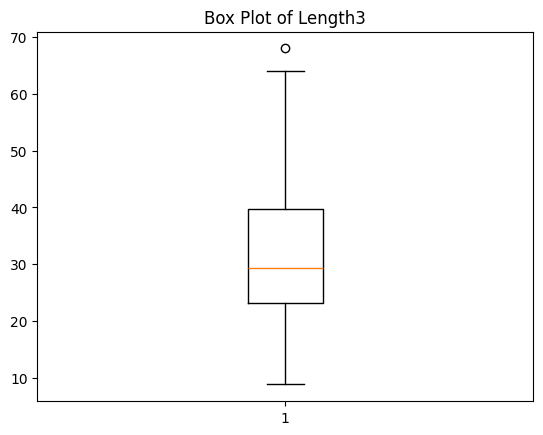

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(df['Length3'])
plt.title("Box Plot of Length3")
plt.show()

In [ ]:
# IQR Method
Q1 = df['Length3'].quantile(0.25)
Q3 = df['Length3'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("\nLower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Find outliers
outliers = df[(df['Length3'] < lower_limit) | (df['Length3'] > upper_limit)]

print("\nOutliers:")
print(outliers)

print("\nNumber of Outliers:", len(outliers))


Lower Limit: -1.600000000000012
Upper Limit: 64.40000000000002

Outliers:
    Species  Weight  Length1  Length2  Length3  Height  Width
144    Pike  1650.0     59.0     63.4     68.0  10.812   7.48

Number of Outliers: 1


In [ ]:
x = df['Length3']
y = df['Weight']

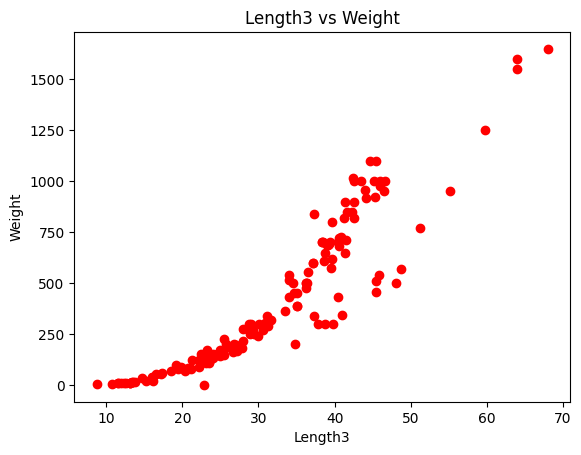

In [ ]:
plt.scatter(x, y, color='red')
plt.xlabel('Length3')
plt.ylabel('Weight')
plt.title('Length3 vs Weight')
plt.show()

In [ ]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=123)

In [ ]:
print('First 5 rows of x_train:')
display(x_train.head())
print('\nFirst 5 rows of y_train:')
display(y_train.head())

First 5 rows of x_train:


,Length3
13,37.3
62,17.4
24,40.5
145,10.8
41,23.1



First 5 rows of y_train:


,Weight
13,340.0
62,60.0
24,700.0
145,6.7
41,110.0


In [ ]:
print('First 5 rows of x_test:')
display(x_test.head())
print('\nFirst 5 rows of y_test:')
display(y_test.head())

First 5 rows of x_test:


,Length3
136,45.8
110,36.5
148,12.0
89,23.5
31,44.0



First 5 rows of y_test:


,Weight
136,540.0
110,556.0
148,9.7
89,135.0
31,955.0


In [ ]:
#model building
regressor=LinearRegression()
regressor.fit(x_train.values.reshape(-1, 1),y_train)

LinearRegression()

In [ ]:
print("Number of instances for training:",(len(x_train)))
print("Number of instances for testing:",(len(x_test)))

Number of instances for training: 135
Number of instances for testing: 24


In [ ]:
poly_features=PolynomialFeatures(degree=2)

In [ ]:
x_poly=poly_features.fit_transform(x_train.values.reshape(-1,1))

In [ ]:
regressor_poly=LinearRegression()
regressor_poly.fit(x_poly,y_train)

LinearRegression()

In [ ]:
#predictions
y_pred=regressor_poly.predict(poly_features.transform(x_test.values.reshape(-1,1)))

In [ ]:
model = LinearRegression()
x_train_poly_local = poly_features.transform(x_train.values.reshape(-1,1))
model.fit(x_train_poly_local, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
model.fit(x_poly,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_poly)
df=pd.DataFrame({'Actual':y_train,'Predicted':y_pred})
print(df)

     Actual   Predicted
13    340.0  531.110535
62     60.0   42.514292
24    700.0  631.018524
145     6.7  -69.041334
41    110.0  159.097638
..      ...         ...
17    700.0  567.883182
98    188.0  230.377999
66    140.0  161.310399
126  1000.0  816.549055
109   514.0  434.272760

[135 rows x 2 columns]


In [ ]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
y_pred_train = regressor_poly.predict(poly_features.transform(x_train.values.reshape(-1, 1)))
mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred_train)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 86.74549883484313
Mean Squared Error (MSE): 15782.525608126756
Root MSE (RMSE): 125.62852227152382
R2 Score: 0.8770510873860896


In [ ]:
# Evaluate model performance on test data using MAE, MSE, RMSE, and R2 score
y_pred_test = regressor_poly.predict(poly_features.transform(x_test.values.reshape(-1, 1)))
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)
print("Mean Absolute Error (MAE) on test data:", mae_test)
print("Mean Squared Error (MSE) on test data:", mse_test)
print("Root MSE (RMSE) on test data:", rmse_test)
print("R2 Score on test data:", r2_test)

Mean Absolute Error (MAE) on test data: 94.98323022624072
Mean Squared Error (MSE) on test data: 16896.969797044385
Root MSE (RMSE) on test data: 129.98834485077646
R2 Score on test data: 0.8608020591029496


In [ ]:
predicted_length3 = 5.844556
poly_predicted_length3 = poly_features.transform([[predicted_length3]])
print(f"Predicted value of y when x is {predicted_length3}: {model.predict(poly_predicted_length3)[0]}")

Predicted value of y when x is 5.844556: -136.2691688437592


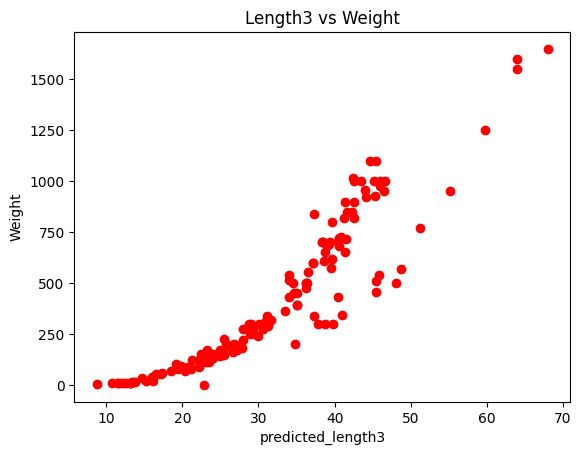

In [ ]:
plt.scatter(x, y, color='red')
plt.xlabel('predicted_length3')
plt.ylabel('Weight')
plt.title('Length3 vs Weight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# All necessary variables (x_test, y_test, y_pred_test) should be
# available from previous successful cell executions.

plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color='red', label='Actual Test Values')
plt.scatter(x_test, y_pred_test, color='blue', label='Predicted Test Values')
plt.xlabel('Length3 (Test Data)')
plt.ylabel('Weight')
plt.title('Actual vs. Predicted Values for Test Data')
plt.legend()
plt.grid(True)
plt.show()